<a href="https://colab.research.google.com/github/Jorge-Ruiz-Troccoli/Data-Science-III/blob/main/Introducci%C3%B3n_Transformers/transformer_nombres_apellidos_VGPU.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🎯 Extracción Nombre/Apellido T5
Versión optimizada para Colab

## ⚙️ 1. Setup

In [ ]:
pip install unidecode

In [ ]:
from unidecode import unidecode
import warnings
import pandas as pd
from sklearn.model_selection import train_test_split
from datasets import Dataset
from transformers import (
    AutoTokenizer, AutoModelForSeq2SeqLM,
    Seq2SeqTrainer, Seq2SeqTrainingArguments,
    DataCollatorForSeq2Seq
)

warnings.filterwarnings("ignore")

MODEL_NAME = "google/flan-t5-small"
PREFIX = "extraer_nombre_apellido: "
OUTPUT_DIR = "mi_modelo_t5"

print("✅ Setup completado")

## 📝 2. Datos

In [ ]:
def strip_accents(text):
    return unidecode(text) if isinstance(text, str) else text

def normalizar(texto):
    if not isinstance(texto, str):
        return texto
    return " ".join(unidecode(texto).upper().split())

df = pd.read_csv("https://raw.githubusercontent.com/Jorge-Ruiz-Troccoli/Data-Science-III/refs/heads/main/Introducci%C3%B3n_Transformers/personas.csv", nrows=20000)[["nombre", "apellido"]].dropna()
df = df.apply(lambda col: col.map(normalizar) if col.dtype == "object" else col)
df = df[(df["nombre"].str.len() > 0) & (df["apellido"].str.len() > 0)].reset_index(drop=True)


# 🔄 Generar variantes
target = "nombre: " + df["nombre"] + " apellido: " + df["apellido"]

dataset_df = pd.concat([
    pd.DataFrame({"input": PREFIX + df["nombre"] + " " + df["apellido"], "target": target}),
    pd.DataFrame({"input": PREFIX + df["apellido"] + " " + df["nombre"], "target": target}),
], ignore_index=True).sample(frac=1, random_state=42).reset_index(drop=True)



In [ ]:
dataset_df

## 🔧 3. Tokenización (SIN paralelo)

In [ ]:
# 🎲 Split 80/20
train_df, val_df = train_test_split(dataset_df, test_size=0.2, random_state=42)

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
#Descarga el tokenizer de flan-t5-small. El tokenizer convierte texto → números (ids), porque el modelo no entiende texto, solo números.

def tokenize(batch):
    inputs = tokenizer(batch["input"], max_length=64, truncation=True, padding=False)
    """
Convierte la columna input (ej: "extraer_nombre_apellido: JORGE RUIZ") a ids. max_length=64 corta si es más largo que eso.
padding=False significa que no rellena con ceros todavía (eso lo hace después el collator, más eficiente).
"""
    labels = tokenizer(text_target=batch["target"], max_length=64, truncation=True, padding=False)
    inputs["labels"] = labels["input_ids"]
    return inputs

"""
Acá tokeniza la salida esperada, target (ej: "nombre: JORGE apellido: RUIZ"). text_target= le dice al tokenizer "esto es la salida,
no la entrada" (algunos modelos tokenizan distinto input vs output).
Esos ids se guardan como labels — es lo que el modelo va a intentar predecir durante el entrenamiento.
Entonces cada fila termina con: input_ids (la pregunta tokenizada) + labels (la respuesta tokenizada).
  """




train_ds = Dataset.from_pandas(train_df, preserve_index=False).map(
    tokenize, batched=True, batch_size=32, remove_columns=["input", "target"]
)
val_ds = Dataset.from_pandas(val_df, preserve_index=False).map(
    tokenize, batched=True, batch_size=32, remove_columns=["input", "target"]
)

"""
Dataset.from_pandas convierte tu DataFrame de pandas a un objeto Dataset (formato que espera la librería datasets,
 más eficiente que pandas para entrenar). .map(tokenize, batched=True, batch_size=32) aplica la función tokenize en lotes de 32 filas a
 la vez (más rápido que fila por fila). remove_columns=["input", "target"] borra las columnas de texto original
  porque ya no las necesitás — el modelo solo usa los ids numéricos.
"""
print(f"✅ Train: {len(train_ds)}, Val: {len(val_ds)}")
print(f"📍 Ejemplo: {tokenizer.decode(train_ds[0]['input_ids'][:10])}...")

¿Cómo procesa realmente "JORGE RUIZ"?En lugar de asignarle un solo ID a todo el nombre, el tokenizador lo divide en piezas que ya conoce. Si le pasas "JORGE RUIZ", lo que ocurre internamente es algo como esto:Lo divide en sub-tokens:" JOR" $\rightarrow$ ID 3129"GE" $\rightarrow$ ID 845" RUI" $\rightarrow$ ID 12901"Z" $\rightarrow$ ID 61Le pasa la secuencia al modelo:
El modelo recibe la lista de números [3129, 845, 12901, 61].

el tokenizador de Flan-T5 se llama SentencePiece (implementando un algoritmo llamado Unigram)

## 🚀 4. Entrenamiento (RÁPIDO)

"Seq2Seq" (sequence-to-sequence) es una arquitectura donde el modelo recibe una secuencia de entrada y devuelve otra secuencia de salida, generada token por token, no una clase o un número fijo. Estructura clásica: encoder + decoder.

In [ ]:
import torch

# QUÉ HACE: detecta si hay GPU (cuda) disponible y define el device.
# POR QUÉ: entrenar/inferir en GPU es mucho más rápido; si no hay, cae a CPU.
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Usando: {device}")

# NUEVO: bf16 (bfloat16) es más estable que fp16 en modelos T5 y evita el
# problema clásico de loss=0 / validation=nan. QUÉ HACE: activa bf16 solo si la
# GPU lo soporta (las T4 de Colab NO lo soportan, las A100/L4 sí). Si no hay
# soporte, se queda en False y se entrena en fp32 (precisión completa, estable).
usar_bf16 = torch.cuda.is_available() and torch.cuda.is_bf16_supported()
print(f"bf16 soportado: {usar_bf16}")


model = AutoModelForSeq2SeqLM.from_pretrained(MODEL_NAME).to(device)


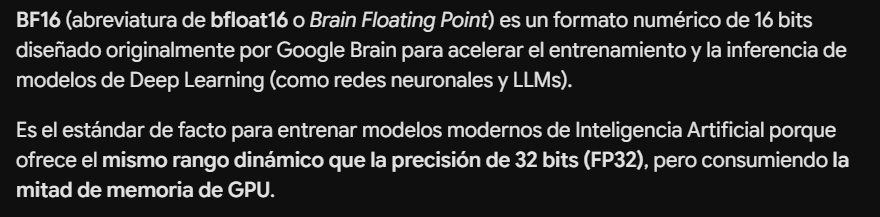

In [ ]:
# Carga el modelo preentrenado de secuencia a secuencia (como T5 o Flan-T5) para tareas de texto a texto
# Agrupa y rellena (padding) los datos dinámicamente por lote, ignorando los pads en la pérdida con label_pad_token_id=-100
collator = DataCollatorForSeq2Seq(tokenizer, model=model, label_pad_token_id=-100, pad_to_multiple_of=8)


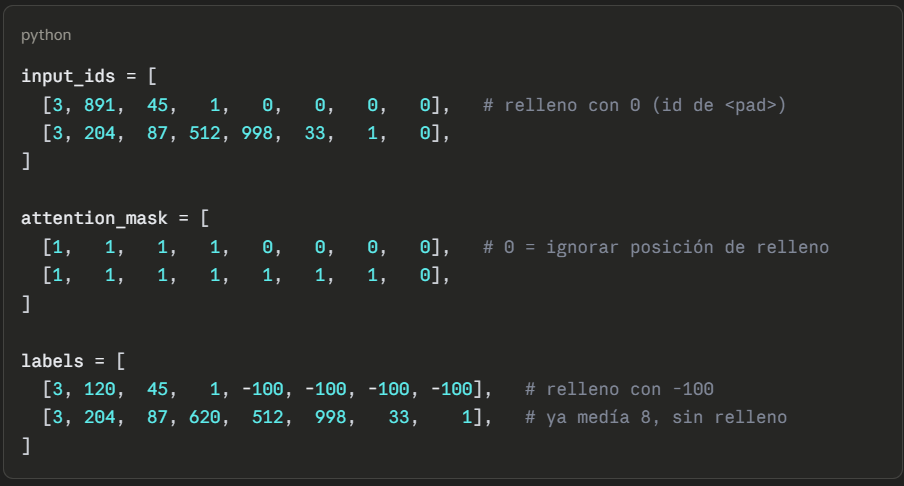

In [ ]:

# ⚡ Config optimizado para velocidad
training_args = Seq2SeqTrainingArguments(
    output_dir=OUTPUT_DIR,              # Carpeta donde se guardarán los checkpoints y el modelo final
    per_device_train_batch_size=16,     # Cantidad de muestras enviadas a la GPU por lote durante el entrenamiento
    per_device_eval_batch_size=16,      # Cantidad de muestras enviadas a la GPU por lote durante la evaluación
    num_train_epochs=2,                 # Veces completas que el modelo pasará por todo el dataset de entrenamiento
    learning_rate=5e-5,                 # Tamaño del paso (ritmo) que usa el optimizador para ajustar los pesos del modelo
    eval_strategy="epoch",              # Evalúa el rendimiento del modelo solo al terminar cada época
    save_strategy="epoch",              # Guarda un checkpoint del modelo al terminar cada época
    load_best_model_at_end=False,       # Lo idea es False porque si la
                                        # validación llega a dar nan, 'el mejor modelo' queda indefinido y
                                        # podría cargar pesos corruptos. En False se conserva el modelo entrenado.
    predict_with_generate=False,        # Desactiva la generación lenta de texto en evaluación para calcular la pérdida rápidamente
    generation_max_length=32,           # Longitud máxima permitida cuando el modelo genera texto durante la inferencia
    logging_steps=50,                   # Imprime métricas en consola/registro cada 50 pasos de entrenamiento
    report_to="none",                   # Desactiva la integración con plataformas externas de rastreo (como WandB o TensorBoard)
    gradient_accumulation_steps=1,      # Pasos a esperar antes de actualizar los pesos (1 = actualiza inmediatamente en cada batch)
    fp16=False,                         # IMPORTANTE: fp16 rompe a T5 (causa loss=0 y validation=nan). Debe quedar en False.
    bf16=usar_bf16,                     # usa bf16 solo si la GPU lo soporta. bf16 es estable en T5 (fp16 no).
    max_grad_norm=1.0,                  # recorta los gradientes para evitar que 'exploten' y generen nan.
)

# 🏋️ Entrenar
trainer = Seq2SeqTrainer(
    model=model,                        # El modelo que se va a entrenar
    args=training_args,                 # La configuración de hiperparámetros definida arriba

  train_dataset = train_ds,


    eval_dataset = val_ds,

    data_collator=collator,             # La función encargada de procesar, agrupar y rellenar los datos en cada batch
    processing_class=tokenizer,         # El tokenizador que usará el entrenador para procesar las entradas
)

print("🏋️ Iniciando entrenamiento...")
# Ejecuta el bucle principal de entrenamiento y evaluación
history = trainer.train()

# Imprime el valor de la pérdida (error) promedio al finalizar todo el entrenamiento
print(f"✅ Entrenamiento completado. Loss final: {history.training_loss:.4f}")





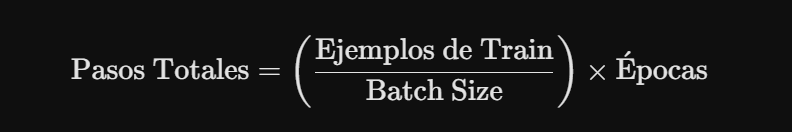

## 💾 5. Guardar

In [ ]:
trainer.save_model(OUTPUT_DIR)
tokenizer.save_pretrained(OUTPUT_DIR)
print(f"✅ Modelo guardado en {OUTPUT_DIR}")

## 🔮 6. Inferencia (GREEDY = RÁPIDO)

In [ ]:

modelo = AutoModelForSeq2SeqLM.from_pretrained(OUTPUT_DIR).to(device)
tokenizer = AutoTokenizer.from_pretrained(OUTPUT_DIR)

def extraer(texto: str) -> str:
    """Extrae nombre y apellido."""

    texto = normalizar(texto)

    ids = tokenizer(PREFIX + texto, return_tensors="pt").input_ids.to(device)
    #return_tensors="pt" le dice al tokenizer que te devuelva los resultados como tensores de PyTorch (pt = PyTorch), en vez de listas normales de Python
    out = modelo.generate(ids, max_length=32)
    #num_beams=1        # sin beam search
  #do_sample=False    # sin muestreo aleatorio
  #esto es greedy

    return tokenizer.decode(out[0], skip_special_tokens=True)


In [ ]:
extraer("lópez da silva maria de los angeles​")